# Your First AI Model in an Hour 🧠👟
### A free Hour of AI lab by Laurence Moroney

<a href="https://colab.research.google.com/github/lmoroney/hourofai/blob/main/lab1-first-model-in-an-hour/first_model_in_an_hour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hi, I'm Laurence. Here's a question for you: **could you write a computer program that can tell a sneaker from a sandal?**

Think about it for a second. What rules would you write? *"If it has laces, it's a sneaker"*? Sandals can have straps that look like laces. *"If it has holes, it's a sandal"*? Some sneakers have mesh. It gets messy fast.

In the next hour you're going to do it a different way. You won't write the rules. You'll show the computer **thousands of examples** and let it *figure out the rules for itself*. That's what machine learning is, and by the end of this notebook you'll have built, trained, tested, and even broken your own AI model.

No experience needed. If you can press a play button, you can do this.

## How this notebook works

There are two kinds of code cells:

- ▶️ **JUST RUN THIS**: click the cell, then press **Shift + Enter** (or the play button on the left). You don't need to understand every line.
- ✏️ **TRY CHANGING THIS**: these cells have a number or word you're invited to change. Change it, run it, see what happens. You can't break anything. If things get weird, use **Runtime → Restart and run all**.

Run the cells **in order, top to bottom**. Let's go!

## Part 0: Get set up

▶️ **JUST RUN THIS.** It loads the tools we need. PyTorch is the library we'll use to build our model. Google Colab already has it installed, so there's nothing to install.

In [1]:
# ▶️ JUST RUN THIS
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)  # makes results repeatable, so your class sees similar numbers
print("Ready! PyTorch version:", torch.__version__)

Ready! PyTorch version: 2.14.1+cpu


## Part 1: What *is* a model?

In regular programming, **you** write the rules:

> data + rules ➡️ answers

In machine learning, we flip that around. We give the computer data *and* the answers, and it works out the rules:

> data + answers ➡️ rules

Those learned "rules" are what we call a **model**. Inside, a model is just a big collection of numbers (we call them **parameters** or **weights**). At first those numbers are random, so the model is basically guessing. During **training**, the computer looks at an example, makes a guess, checks how wrong it was, and nudges its numbers a tiny bit to be less wrong next time. Do that thousands of times, and the guesses get good.

That's it. No magic, no thinking, no understanding. Just lots of tiny corrections. Keep that in mind; it matters a lot later.

## Part 2: Meet the data 👕👖👟

We're going to use a dataset called **Fashion-MNIST**. It has **70,000 small pictures of clothing** in 10 categories, like T-shirts, trousers, sneakers, and bags. Each picture is tiny: 28 × 28 pixels, in grayscale.

We split it into two piles:
- **60,000 training images**: the model learns from these.
- **10,000 test images**: we hide these from the model and use them later to check if it *really* learned, or just memorized.

▶️ **JUST RUN THIS** to download the data (takes a few seconds).

In [2]:
# ▶️ JUST RUN THIS
import contextlib, io
to_tensor = transforms.ToTensor()  # turns each picture into numbers between 0 and 1
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):  # hide download chatter
  train_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=to_tensor)
  test_data  = datasets.FashionMNIST(root="data", train=False, download=True, transform=to_tensor)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Training images:", len(train_data))
print("Test images:    ", len(test_data))

Training images: 60000
Test images:     10000


Let's look at some of them. ▶️ **JUST RUN THIS.**

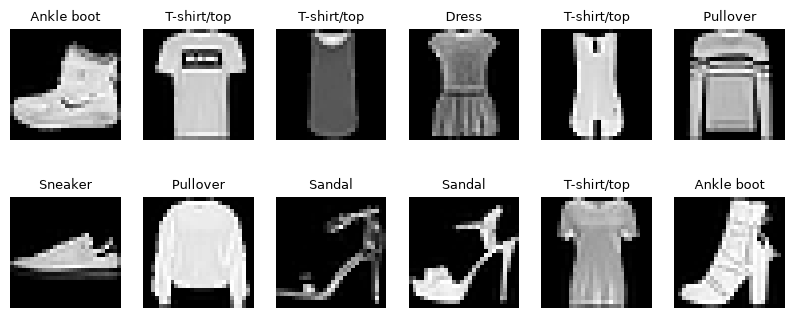

In [3]:
# ▶️ JUST RUN THIS
fig = plt.figure(figsize=(10, 4))
for i in range(12):
    image, label = train_data[i]
    ax = fig.add_subplot(2, 6, i + 1)
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
plt.show()

To a computer, a picture is just a grid of numbers. Each number says how bright that pixel is (0 = black, 1 = white).

✏️ **TRY CHANGING THIS:** change `picture_number` to any number from 0 to 59999 and run the cell. Can *you* tell what it is from the tiny picture?

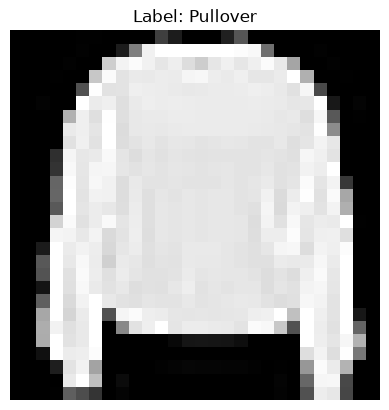

This picture is really a grid of 28 x 28 = 784 numbers.
Here's the top-left corner of the grid:
[[0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.01]
 [0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.  ]]


In [4]:
# ✏️ TRY CHANGING THIS
picture_number = 7

image, label = train_data[picture_number]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {class_names[label]}")
plt.axis("off")
plt.show()
print("This picture is really a grid of", image.shape[1], "x", image.shape[2], "=", image.numel(), "numbers.")
print("Here's the top-left corner of the grid:")
print(image[0, :5, :5].numpy().round(2))

## Part 3: Build a tiny brain (well, sort of)

People call these things **neural networks**. They were loosely inspired by brains, but honestly it's more helpful to think of them as layers of little calculators.

Our network will have three steps:

1. **Flatten**: unroll the 28 × 28 grid into one long line of 784 numbers.
2. **A hidden layer of 128 "neurons"**: each one looks at all 784 pixels and learns to spot some pattern (maybe "there's a straight edge here" or "the bottom is wide").
3. **An output layer of 10 neurons**: one for each type of clothing. Whichever one shouts the loudest is the model's guess.

▶️ **JUST RUN THIS.**

In [5]:
# ▶️ JUST RUN THIS
model = nn.Sequential(
    nn.Flatten(),          # 28x28 picture -> 784 numbers in a row
    nn.Linear(784, 128),   # hidden layer: 128 pattern-spotters
    nn.ReLU(),             # keep only the "yes, I see my pattern" signals
    nn.Linear(128, 10),    # output: one score for each of the 10 classes
)
print(model)
print("Number of parameters (numbers the model can learn):", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
Number of parameters (numbers the model can learn): 101770


Over **100,000** numbers, and right now every one of them is random. So how good is our model *before* training? There are 10 classes, so a random guess would be right about 1 time in 10.

Let's check. ▶️ **JUST RUN THIS.** (This cell also sets up a helper that measures accuracy, so we can reuse it.)

In [6]:
# ▶️ JUST RUN THIS
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1000)

def accuracy(model):
    correct = 0
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            guesses = model(images).argmax(dim=1)
            correct += (guesses == labels).sum().item()
    return 100 * correct / len(test_data)

print(f"Accuracy BEFORE training: {accuracy(model):.1f}%  (random guessing is about 10%)")

Accuracy BEFORE training: 11.7%  (random guessing is about 10%)


## Part 4: Train it! Watch the loss drop 📉

Now the fun part. During training the model will:

1. Look at a small batch of 64 pictures.
2. Guess what each one is.
3. Measure **how wrong** it was. This number is called the **loss**. Big loss = very wrong. Small loss = pretty good.
4. Nudge all 100,000+ numbers a tiny bit to make the loss smaller.
5. Repeat for the next batch...

One full pass through all 60,000 training pictures is called an **epoch**. We'll do 5 epochs. On free Colab this takes about a minute. While it runs, the loss should go **down**. That's the model learning.

▶️ **JUST RUN THIS** first. It defines the training recipe.

In [7]:
# ▶️ JUST RUN THIS (it just defines the recipe; nothing happens yet)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)

def train(model, epochs=5, learning_rate=0.001):
    loss_fn = nn.CrossEntropyLoss()                                  # measures "how wrong"
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  # does the nudging
    losses = []
    for epoch in range(epochs):
        model.train()
        start, total = time.time(), 0.0
        for images, labels in train_loader:
            loss = loss_fn(model(images), labels)  # guess, then measure how wrong
            optimizer.zero_grad()
            loss.backward()                        # work out which way to nudge
            optimizer.step()                       # nudge!
            total += loss.item()
        losses.append(total / len(train_loader))
        print(f"Epoch {epoch + 1}/{epochs}  loss: {losses[-1]:.3f}  "
              f"test accuracy: {accuracy(model):.1f}%  ({time.time() - start:.0f}s)")
    return losses

▶️ **JUST RUN THIS** to start training. Watch the numbers!

Epoch 1/5  loss: 0.554  test accuracy: 84.2%  (3s)


Epoch 2/5  loss: 0.404  test accuracy: 85.2%  (3s)


Epoch 3/5  loss: 0.361  test accuracy: 86.5%  (3s)


Epoch 4/5  loss: 0.332  test accuracy: 86.7%  (3s)


Epoch 5/5  loss: 0.313  test accuracy: 86.7%  (3s)


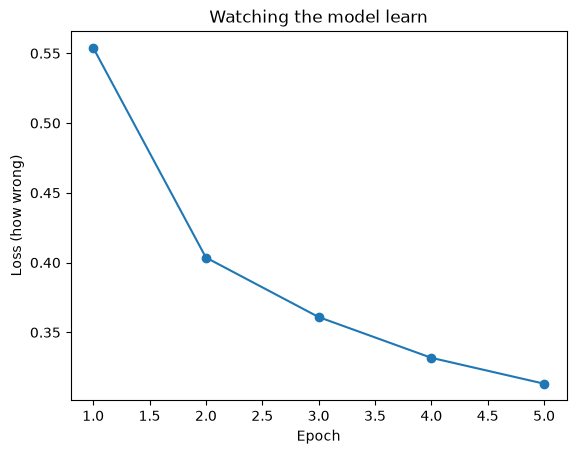

In [8]:
# ▶️ JUST RUN THIS
losses = train(model, epochs=5)

plt.plot(range(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss (how wrong)"); plt.title("Watching the model learn")
plt.show()

**Look at that curve!** The loss went down, and accuracy jumped from about 10% to somewhere around **85-88%**. Nobody told the model what a sneaker looks like. It figured that out from examples.

💬 **Talk about it:** Why do you think the loss drops a lot at the start, and then only a little later on?

## Part 5: Test it 🧪

Remember the 10,000 test pictures the model has **never seen**? This is the real exam. A model that only does well on pictures it already studied is like a student who memorized the answer key. We want one that actually learned.

▶️ **JUST RUN THIS** to see the model's guesses on random test pictures. Green = right, red = wrong. Run it a few times to see different pictures!

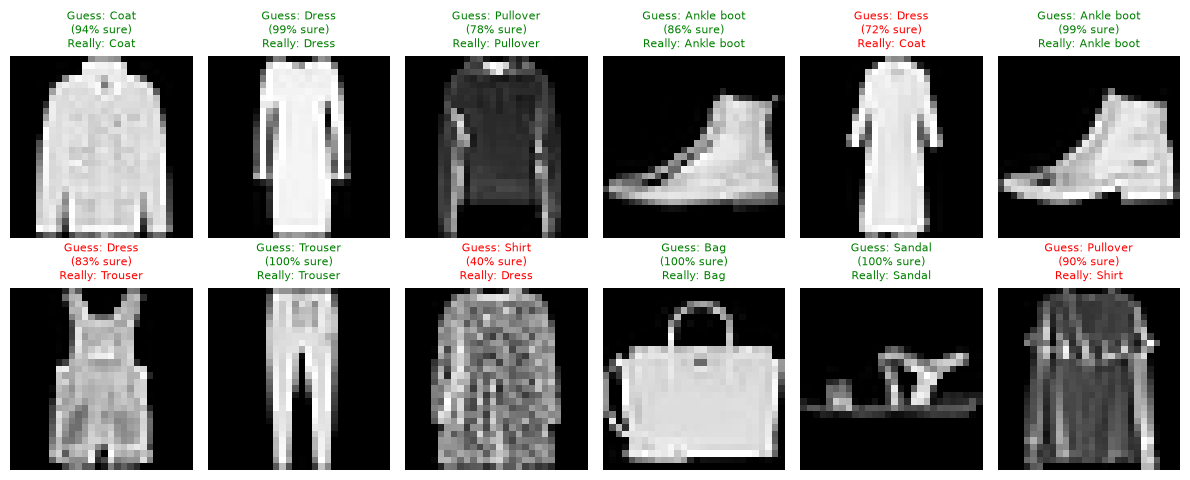

Overall test accuracy: 86.7%


In [9]:
# ▶️ JUST RUN THIS (run it again for new pictures)
model.eval()
fig = plt.figure(figsize=(12, 5))
for i in range(12):
    idx = torch.randint(len(test_data), (1,)).item()
    image, label = test_data[idx]
    with torch.no_grad():
        probs = torch.softmax(model(image.unsqueeze(0)), dim=1)[0]
    guess = probs.argmax().item()
    ax = fig.add_subplot(2, 6, i + 1)
    ax.imshow(image.squeeze(), cmap="gray"); ax.axis("off")
    ax.set_title(f"Guess: {class_names[guess]}\n({100 * probs[guess]:.0f}% sure)\nReally: {class_names[label]}",
                 fontsize=8, color="green" if guess == label else "red")
plt.tight_layout(); plt.show()
print(f"Overall test accuracy: {accuracy(model):.1f}%")

## Part 6: Your turn. Be the AI engineer 🔧

Real AI engineers spend a lot of their time doing exactly this: change one thing, retrain, compare. Let's try two experiments. First, ▶️ **JUST RUN THIS** helper:

In [10]:
# ▶️ JUST RUN THIS
def build_and_train(hidden_neurons=128, epochs=3, learning_rate=0.001):
    torch.manual_seed(42)
    new_model = nn.Sequential(nn.Flatten(), nn.Linear(784, hidden_neurons), nn.ReLU(),
                              nn.Linear(hidden_neurons, 10))
    print(f"Training with {hidden_neurons} hidden neurons, {epochs} epochs, learning rate {learning_rate}")
    train(new_model, epochs=epochs, learning_rate=learning_rate)
    return new_model

### 🧪 Experiment A: How big does the brain need to be?

Our model had 128 hidden neurons. What if it had just **8**? Or **512**?

✏️ **TRY CHANGING THIS:** first *predict* what will happen and write it down. Then change `hidden_neurons` and run. Try at least two different numbers.

| hidden_neurons | my prediction | actual accuracy |
|---|---|---|
| 8 | | |
| 512 | | |

In [11]:
# ✏️ TRY CHANGING THIS (try 8, 32, 512...)
hidden_neurons = 8

experiment_model = build_and_train(hidden_neurons=hidden_neurons, epochs=3)

Training with 8 hidden neurons, 3 epochs, learning rate 0.001


Epoch 1/3  loss: 0.939  test accuracy: 76.7%  (3s)


Epoch 2/3  loss: 0.591  test accuracy: 80.0%  (3s)


Epoch 3/3  loss: 0.534  test accuracy: 81.0%  (3s)


Did a bigger brain help? Often a bigger model helps *a bit*, but it's slower and the gains shrink. Tiny models can be surprisingly good. Knowing "how big is big enough" is a real engineering skill.

### 🧪 Experiment B: How big are the nudges?

The **learning rate** controls how big each nudge is. Too small and the model learns very slowly. Too big and it overshoots, like trying to park a car by flooring the gas pedal.

✏️ **TRY CHANGING THIS:** try `0.1` (huge nudges) and `0.00001` (teeny nudges). Watch the loss. What happens?

In [12]:
# ✏️ TRY CHANGING THIS (try 0.1, then 0.00001)
learning_rate = 0.1

experiment_model = build_and_train(hidden_neurons=128, epochs=3, learning_rate=learning_rate)

Training with 128 hidden neurons, 3 epochs, learning rate 0.1


Epoch 1/3  loss: 1.927  test accuracy: 34.0%  (3s)


Epoch 2/3  loss: 1.629  test accuracy: 34.8%  (4s)


Epoch 3/3  loss: 1.603  test accuracy: 32.8%  (4s)


💬 **Talk about it:** Which setting gave the best accuracy in your class? Did anyone find something better than what I started with? (If so, tell your teacher! That's exactly how research works.)

## Part 7: Where AI goes wrong ⚠️

This is, in my opinion, the most important part of the whole lab.

Our model is right most of the time. But "most of the time" means it's **wrong** hundreds of times on the test set. Let's look at its mistakes. ▶️ **JUST RUN THIS.**

The model got 1334 out of 10000 test pictures wrong. Here are some:


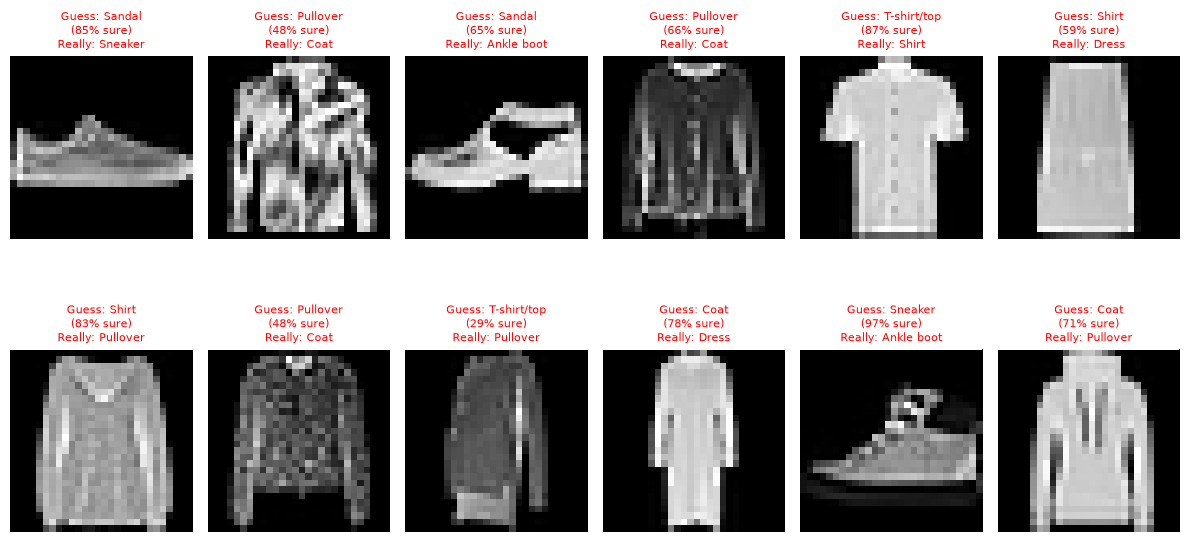

In [13]:
# ▶️ JUST RUN THIS
model.eval()
with torch.no_grad():
    all_images = torch.stack([img for img, _ in test_data])
    all_labels = torch.tensor([lbl for _, lbl in test_data])
    all_probs  = torch.softmax(model(all_images), dim=1)
    all_guesses = all_probs.argmax(dim=1)

wrong = (all_guesses != all_labels).nonzero().squeeze()
print(f"The model got {len(wrong)} out of {len(test_data)} test pictures wrong. Here are some:")

fig = plt.figure(figsize=(12, 6.5))
for i, idx in enumerate(wrong[:12]):
    ax = fig.add_subplot(2, 6, i + 1)
    ax.imshow(all_images[idx].squeeze(), cmap="gray"); ax.axis("off")
    ax.set_title(f"Guess: {class_names[all_guesses[idx]]}\n({100 * all_probs[idx].max():.0f}% sure)\n"
                 f"Really: {class_names[all_labels[idx]]}", fontsize=8, color="red")
plt.tight_layout(); plt.show()

Look closely at the percentages. Sometimes the model is **very sure** and still **wrong**. AI doesn't know when it doesn't know.

Now let's see *which* kinds of clothing it struggles with. ▶️ **JUST RUN THIS.**

In [14]:
# ▶️ JUST RUN THIS
print("Accuracy for each type of clothing:\n")
for c, name in enumerate(class_names):
    mask = all_labels == c
    acc = 100 * (all_guesses[mask] == c).float().mean().item()
    print(f"{name:12s} {'█' * int(acc / 4):25s} {acc:.0f}%")

Accuracy for each type of clothing:

T-shirt/top  █████████████████████     85%
Trouser      ███████████████████████   95%
Pullover     ████████████████          65%
Dress        █████████████████████     87%
Coat         ██████████████████████    88%
Sandal       ███████████████████████   96%
Shirt        ████████████████          65%
Sneaker      ███████████████████████   94%
Bag          ████████████████████████  97%
Ankle boot   ███████████████████████   95%


The model is great at some things (trousers, bags) and much worse at others. **Shirts** and **pullovers** are usually the hardest. They get mixed up with T-shirts, coats, and each other. Honestly, at 28 × 28 pixels, I'd struggle too!

Here's the key idea: **the model's overall score hides the fact that it works much better for some groups than others.** Now imagine this wasn't clothing. Imagine it was a model looking at faces, or medical scans, or job applications. An "88% accurate" system could be 98% accurate for some people and much worse for others. That's what people mean when they talk about **bias in AI**.

### One more test: the real world

Every picture in Fashion-MNIST was taken the same way: a light-colored item on a **black background**, centered, from one online store's catalog. What happens if we show the model something a little different, like the *same* boot on a **white background**, the way you might photograph it at home?

▶️ **JUST RUN THIS.**

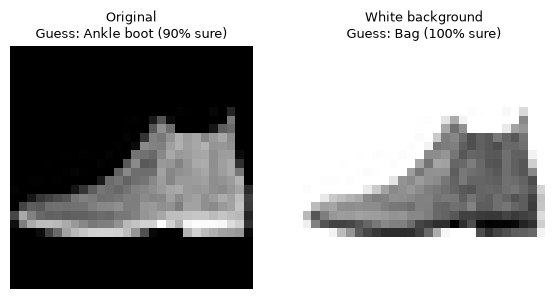

Really: Ankle boot


In [15]:
# ▶️ JUST RUN THIS
image, label = test_data[0]         # a picture of an ankle boot
flipped = 1 - image                 # same boot, colors inverted: dark boot on a white background

model.eval()
fig = plt.figure(figsize=(6, 3))
for i, (img, desc) in enumerate([(image, "Original"), (flipped, "White background")]):
    with torch.no_grad():
        probs = torch.softmax(model(img.unsqueeze(0)), dim=1)[0]
    ax = fig.add_subplot(1, 2, i + 1)
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"{desc}\nGuess: {class_names[probs.argmax()]} ({100 * probs.max():.0f}% sure)", fontsize=9)
plt.tight_layout(); plt.show()
print("Really:", class_names[label])

To you and me, that's obviously the same boot. To the model, it's a totally different grid of numbers, and it has never seen anything like it. So it gets confused, and it may even be confident about the wrong answer.

This is one of the most important lessons in AI: **a model only knows the world it was trained on.** It didn't learn "what a boot is." It learned patterns in *these particular pictures*. When the real world looks different from the training data, models can fail, sometimes badly, and sometimes without any warning.

💬 **Talk about it:**
1. Where did this data come from, and who chose it? What kinds of clothing are *missing*? (Think: clothes from different cultures, shoes like sandals with socks, hats, a sari, a hijab...)
2. The model was "88% accurate." Is that good enough to sort clothes in a warehouse? To help a blind person pick an outfit? What about a model used in a hospital? Who decides what's "good enough"?
3. The model sometimes said it was 90%+ sure and was still wrong. Why might that be dangerous if people trust it too much?
4. How would you make this model fairer or more reliable?

## 🎉 You did it!

In about an hour you:

- ✅ Learned that a model is a big set of numbers that learns rules from examples
- ✅ Explored a real dataset of 70,000 images
- ✅ Built a neural network with over 100,000 parameters
- ✅ Trained it and watched the loss drop
- ✅ Tested it on pictures it had never seen
- ✅ Ran your own experiments like a real AI engineer
- ✅ Found where it fails, and thought about why that matters

That last one might be the most important. The world needs people who can build AI **and** people who can ask hard questions about it. You're now one of them.

### 📝 Exit ticket
Finish this sentence in your own words: *"An AI model is... and it can go wrong when..."*

### Want to keep going?
- Try training for 10 epochs instead of 5. Does it keep getting better?
- Look up **convolutional neural networks (CNNs)**. They're designed for images and can beat 90% on this dataset.
- More from me: [my blog](https://laurencemoroney.com) and [my PyTorch book](https://link.amazon/B0eNBlqeN)

Thanks for learning with me. Keep building, keep asking questions. — Laurence